# Healthcare Fraud Detection
This notebook applies the same end-to-end pipeline used in `Fraud_code_final.ipynb` (EDA → cleaning → preprocessing → SMOTE → model training → hyperparameter tuning (including SMOTE) → evaluation) to the Kaggle **Healthcare Fraud Detection Dataset** (https://www.kaggle.com/datasets/nudratabbas/healthcare-fraud-detection-dataset).

Target column: `Is_Fraud` (0 = legitimate claim, 1 = fraudulent claim).

> **Fixes applied to this version:**
> - Dropped `Provider_ID` (previously left in the data despite the text below saying it would be removed) — as a high-cardinality ID it risked leaking provider-specific fraud labels from train into test.
> - Defined `rf_auc` / `xgb_auc` before they're used in the Random Forest / XGBoost evaluation and ROC-curve cells (previously undefined — would raise `NameError` on a fresh run).
> - Fixed `num_features1 = num_features.remove(...)` which incorrectly set `num_features1` to `None` (`list.remove()` returns `None`).
> - Made the preprocessing `ColumnTransformer` reuse the manually curated `cat_features` / `num_features1` lists instead of silently re-deriving them by dtype, so `Chronic_Condition_Flag` and `Claim_Submission_Month` are one-hot encoded as originally intended rather than scaled.


In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data

In [40]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nudratabbas/healthcare-fraud-detection-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'healthcare-fraud-detection-dataset' dataset.
Path to dataset files: /kaggle/input/healthcare-fraud-detection-dataset


In [41]:
import os

# Locate the CSV file inside the downloaded dataset folder
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
csv_path = os.path.join(path, csv_file)
print("Reading:", csv_path)

df = pd.read_csv(csv_path)
df.head(2)

Reading: /kaggle/input/healthcare-fraud-detection-dataset/healthcare_fraud_detection.csv


,Provider_ID,Claim_ID,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Claim_Submission_Date,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Is_Fraud,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m
0,P0052,C0000000,37,Male,I25.10,36415,443.51,393.16,Medicaid,2024-09-01,13,70,Cardiology,NY,Approved,0,0,Outpatient,1,2.0
1,P0121,C0000001,21,Female,E11.9,99213,467.50,461.33,Self-Pay,2022-09-05,5,62,General Practice,IL,Pending,0,5,Inpatient,1,2.0


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Provider_ID                            10000 non-null  object 
 1   Claim_ID                               10000 non-null  object 
 2   Patient_Age                            10000 non-null  int64  
 3   Patient_Gender                         10000 non-null  object 
 4   Diagnosis_Code                         10000 non-null  object 
 5   Procedure_Code                         10000 non-null  int64  
 6   Claim_Amount                           10000 non-null  float64
 7   Approved_Amount                        10000 non-null  float64
 8   Insurance_Type                         9650 non-null   object 
 9   Claim_Submission_Date                  10000 non-null  object 
 10  Days_Between_Service_and_Claim         10000 non-null  int64  
 11  Num

In [43]:
df.describe()

,Patient_Age,Procedure_Code,Claim_Amount,Approved_Amount,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Is_Fraud,Length_of_Stay,Chronic_Condition_Flag,Prior_Visits_12m
count,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,9650.000000
mean,49.755000,86905.21170,572.804406,475.514157,14.413800,68.628000,0.082900,2.19930,0.292000,3.026425
std,17.910144,14965.32496,406.202437,323.257165,8.489875,14.905872,0.275745,1.71046,0.454705,1.722789
min,1.000000,36415.00000,60.210000,50.350000,0.000000,42.000000,0.000000,0.00000,0.000000,0.000000
25%,37.750000,80053.00000,305.205000,257.200000,7.000000,60.000000,0.000000,1.00000,0.000000,2.000000
50%,50.000000,93000.00000,461.225000,388.370000,14.000000,66.000000,0.000000,2.00000,0.000000,3.000000
75%,62.000000,99213.00000,711.365000,598.347500,22.000000,72.000000,0.000000,3.00000,1.000000,4.000000
max,95.000000,99214.00000,6590.700000,4270.890000,29.000000,144.000000,1.000000,5.00000,1.000000,12.000000


In [44]:
df.shape

(10000, 20)

## 2. Missing Values

In [45]:
##Checking for Missing Observations
df.isnull().sum()

,0
Provider_ID,0
Claim_ID,0
Patient_Age,0
Patient_Gender,0
Diagnosis_Code,0
Procedure_Code,0
Claim_Amount,0
Approved_Amount,0
Insurance_Type,350
Claim_Submission_Date,0


In [46]:
#Checking Missing Values
features=[i for i in df.columns if df[i].isnull().sum()>=1]
for j in features:
    print(j,np.round(df[j].isnull().mean()*100,5),'% missing values')

Insurance_Type 3.5 % missing values
Provider_Specialty 3.5 % missing values
Prior_Visits_12m 3.5 % missing values


In [47]:
df.isnull().sum()

,0
Provider_ID,0
Claim_ID,0
Patient_Age,0
Patient_Gender,0
Diagnosis_Code,0
Procedure_Code,0
Claim_Amount,0
Approved_Amount,0
Insurance_Type,350
Claim_Submission_Date,0


## 3. Feature Cleanup
`Provider_ID`, `Claim_ID` are unique identifiers with no predictive value. `Claim_Submission_Date` is a raw date string; we extract a `Claim_Submission_Month` feature from it (to capture any seasonality) and drop the original date column. `Procedure_Code` is numeric but represents a small set of discrete billing codes (CPT-style), so we cast it to a categorical/string type so it gets one-hot encoded rather than scaled.

In [48]:
#Feature engineering from the claim submission date
df['Claim_Submission_Date'] = pd.to_datetime(df['Claim_Submission_Date'])
df['Claim_Submission_Month'] = df['Claim_Submission_Date'].dt.month

#Removing insignificant Features (unique identifiers with no predictive value)
df.drop(['Claim_ID','Provider_ID','Claim_Submission_Date'],axis=1,inplace=True)

#Procedure_Code is a discrete billing code, not a continuous numeric quantity -> treat as categorical
df['Procedure_Code'] = df['Procedure_Code'].astype(str)


In [49]:
##To check all unique values
df['Insurance_Type'].value_counts()

,count
Insurance_Type,
Medicare,2425
Medicaid,2419
Private,2405
Self-Pay,2401


In [50]:
## get all the numeric features
num_features = [feature for feature in df.columns if df[feature].dtype != 'O']
print('Num of Numerical Features :', len(num_features))
num_features = [col for col in num_features if col not in ['Chronic_Condition_Flag', 'Claim_Submission_Month']]
num_features


Num of Numerical Features : 10


['Patient_Age',
 'Claim_Amount',
 'Approved_Amount',
 'Days_Between_Service_and_Claim',
 'Number_of_Claims_Per_Provider_Monthly',
 'Is_Fraud',
 'Length_of_Stay',
 'Prior_Visits_12m']

In [51]:
##get all the categorical features
cat_features = ['Patient_Gender', 'Diagnosis_Code', 'Procedure_Code', 'Insurance_Type', 'Provider_Specialty', 'Patient_State', 'Claim_Status', 'Visit_Type', 'Chronic_Condition_Flag', 'Claim_Submission_Month']
print('Num of Categorical Features :', len(cat_features))
cat_features


Num of Categorical Features : 10


['Patient_Gender',
 'Diagnosis_Code',
 'Procedure_Code',
 'Insurance_Type',
 'Provider_Specialty',
 'Patient_State',
 'Claim_Status',
 'Visit_Type',
 'Chronic_Condition_Flag',
 'Claim_Submission_Month']

In [52]:
num_features1 = num_features.copy()
num_features1.remove('Is_Fraud')


In [53]:
##Discrete Features
disc_feat=[features for features in num_features if len(df[features].unique())<=25 ]
print(len(disc_feat))

3


In [54]:
##Continuous Features
cont_feat=[features for features in num_features if features not in disc_feat ]
print(len(cont_feat))

5


In [55]:
df.shape

(10000, 18)

## MACHINE LEARNING TRAINING

In [56]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.metrics import roc_auc_score,roc_curve,recall_score,f1_score,precision_score,accuracy_score
from sklearn.metrics import average_precision_score

In [57]:
y_old=df['Is_Fraud']  #Dependent Features
x_old=df.drop('Is_Fraud',axis=1) #Independent Features
x_old.head(2)

,Patient_Age,Patient_Gender,Diagnosis_Code,Procedure_Code,Claim_Amount,Approved_Amount,Insurance_Type,Days_Between_Service_and_Claim,Number_of_Claims_Per_Provider_Monthly,Provider_Specialty,Patient_State,Claim_Status,Length_of_Stay,Visit_Type,Chronic_Condition_Flag,Prior_Visits_12m,Claim_Submission_Month
0,37,Male,I25.10,36415,443.51,393.16,Medicaid,13,70,Cardiology,NY,Approved,0,Outpatient,1,2.0,9
1,21,Female,E11.9,99213,467.50,461.33,Self-Pay,5,62,General Practice,IL,Pending,5,Inpatient,1,2.0,9


In [58]:
#Splitting BEFORE any encoding/scaling/SMOTE so nothing from the test set leaks into training
x_train_raw, x_test_raw, y_train, y_test = train_test_split(
    x_old, y_old, test_size=0.3, random_state=42, stratify=y_old
)
train_df = x_train_raw.copy()
train_df['Is_Fraud'] = y_train.values

# Create testing DataFrame
test_df = x_test_raw.copy()
test_df['Is_Fraud'] = y_test.values
print('Train shape:', x_train_raw.shape, ' Test shape:', x_test_raw.shape)

Train shape: (7000, 17)  Test shape: (3000, 17)


##Impurting missing values separately for Train and Test to avoid data leakage


In [59]:
#Replacing null values with the median for numerical features and mode for categorical features
train_df['Prior_Visits_12m'] = train_df['Prior_Visits_12m'].fillna(train_df['Prior_Visits_12m'].median())
train_df['Insurance_Type'] = train_df['Insurance_Type'].fillna(train_df['Insurance_Type'].mode()[0])
train_df['Provider_Specialty'] = train_df['Provider_Specialty'].fillna(train_df['Provider_Specialty'].mode()[0])

x_train = train_df.drop(columns=['Is_Fraud'])
y_train = train_df['Is_Fraud']


In [60]:
#Replacing null values with the median for numerical features and mode for categorical features
test_df['Prior_Visits_12m'] = test_df['Prior_Visits_12m'].fillna(test_df['Prior_Visits_12m'].median())
test_df['Insurance_Type'] = test_df['Insurance_Type'].fillna(test_df['Insurance_Type'].mode()[0])
test_df['Provider_Specialty'] = test_df['Provider_Specialty'].fillna(test_df['Provider_Specialty'].mode()[0])

x_test = test_df.drop(columns=['Is_Fraud'])
y_test = test_df['Is_Fraud']

In [61]:
# Reuse the manually curated cat_features (cell 16) and num_features1 (cell 17)
# lists so Chronic_Condition_Flag / Claim_Submission_Month stay treated as
# categorical, as originally intended, instead of being silently re-derived
# from dtype (which would route them to StandardScaler instead of OneHotEncoder).

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(drop='first', handle_unknown='ignore')

preprocessor = ColumnTransformer(
    [
         ("OneHotEncoder", oh_transformer, cat_features),  #OneHot Encoding for categorical features
          ("StandardScaler", numeric_transformer, num_features1) #Normalisation of Numerical Features
    ]
)


In [62]:
x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)

In [63]:
y_train.value_counts()

,count
Is_Fraud,
0,6420
1,580


In [64]:
sm = SMOTE(random_state=42)
x_train_res, y_train_res = sm.fit_resample(x_train, y_train)  #For the first few models without cross validation.

In [65]:
y_train_res.value_counts()

,count
Is_Fraud,
0,6420
1,6420


In [66]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss'),
    "KNeighborsClassifier": KNeighborsClassifier()
}

for i in range(len(list(models))):
    model = list(models.values())[i]

    # Train on SMOTE-resampled TRAINING data only
    model.fit(x_train_res, y_train_res)

    # Make predictions
    y_train_pred = model.predict(x_train_res)
    y_test_pred = model.predict(x_test)

    # Predicted probabilities for positive class
    y_train_prob = model.predict_proba(x_train_res)[:, 1]
    y_test_prob = model.predict_proba(x_test)[:, 1]

    # AUC-PR
    train_auc_pr = average_precision_score(y_train_res, y_train_prob)
    test_auc_pr = average_precision_score(y_test, y_test_prob)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train_res, y_train_pred)
    model_train_f1 = f1_score(y_train_res, y_train_pred, average='weighted')
    model_train_precision = precision_score(y_train_res, y_train_pred)
    model_train_recall = recall_score(y_train_res, y_train_pred)

    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)

    print(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print("- F1 score: {:.4f}".format(model_train_f1))
    print("- Precision: {:.4f}".format(model_train_precision))
    print("- Recall: {:.4f}".format(model_train_recall))
    print("- AUC-PR: {:.4f}".format(train_auc_pr))

    print('----------------------------------')

    print('Model performance for Test set')
    print("- Accuracy: {:.4f}".format(model_test_accuracy))
    print("- F1 score: {:.4f}".format(model_test_f1))
    print("- Precision: {:.4f}".format(model_test_precision))
    print("- Recall: {:.4f}".format(model_test_recall))
    print("- AUC-PR: {:.4f}".format(test_auc_pr))

    print('=' * 35)
    print('\n')

Logistic Regression
Model performance for Training set
- Accuracy: 0.9925
- F1 score: 0.9925
- Precision: 0.9896
- Recall: 0.9955
- AUC-PR: 0.9998
----------------------------------
Model performance for Test set
- Accuracy: 0.9857
- F1 score: 0.9858
- Precision: 0.8962
- Recall: 0.9357
- AUC-PR: 0.9807


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- AUC-PR: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9623
- F1 score: 0.9631
- Precision: 0.7482
- Recall: 0.8233
- AUC-PR: 0.6306


Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
- AUC-PR: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.9613
- F1 score: 0.9603
- Precision: 0.8009
- Recall: 0.7108
- AUC-PR: 0.8713


XGBoost
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precisio

In [67]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import RandomizedSearchCV

# ---------------------------------------------------
# KNN Pipeline
# ---------------------------------------------------

knn_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', KNeighborsClassifier())
])


# ---------------------------------------------------
# KNN Hyperparameter Distribution
# ---------------------------------------------------

knn_params = {
    'model__n_neighbors': [3, 5, 7, 9, 11, 15, 20, 25],
    'model__weights': ['uniform', 'distance'],
    'model__p': [1, 2],
    'model__leaf_size': [20, 30, 40, 50]
}


# ---------------------------------------------------
# Randomized Search
# ---------------------------------------------------

knn_random = RandomizedSearchCV(
    estimator=knn_pipeline,
    param_distributions=knn_params,
    n_iter=16,
    cv=3,
    scoring='roc_auc',
    verbose=2,
    n_jobs=-1,
    random_state=42
)


# IMPORTANT: use original training data
# SMOTE happens separately within each CV fold
knn_random.fit(x_train, y_train)


# ---------------------------------------------------
# Best Parameters
# ---------------------------------------------------

knn_best_params = knn_random.best_params_

print("---------------- Best Params for KNN ----------------")
print(knn_best_params)

print("\nBest CV AUC-PR:", knn_random.best_score_)

Fitting 3 folds for each of 16 candidates, totalling 48 fits
---------------- Best Params for KNN ----------------
{'model__weights': 'uniform', 'model__p': 2, 'model__n_neighbors': 25, 'model__leaf_size': 40}

Best CV AUC-PR: 0.9469206349642172


In [68]:
 # ---------------------------------------------------
# Fit Final Tuned KNN on SMOTE-resampled training data
# ---------------------------------------------------

# Remove 'model__' prefix from pipeline parameter names
knn_best_params = {
    k.replace('model__', ''): v
    for k, v in knn_random.best_params_.items()
}

knn_model = KNeighborsClassifier(**knn_best_params)

# Fit on the full SMOTE-resampled training data
knn_model.fit(x_train_res, y_train_res)


# ---------------------------------------------------
# Predictions on untouched test data
# ---------------------------------------------------

knn_pred = knn_model.predict(x_test)
knn_proba = knn_model.predict_proba(x_test)[:, 1]


# ---------------------------------------------------
# Evaluation
# ---------------------------------------------------

knn_auc = roc_auc_score(y_test, knn_proba)
knn_auc_pr = average_precision_score(y_test, knn_proba)

print("Tuned KNN")
print("Accuracy =", accuracy_score(y_test, knn_pred))
print("Precision =", precision_score(y_test, knn_pred, zero_division=0))
print("Recall =", recall_score(y_test, knn_pred, zero_division=0))
print("F1 Score =", f1_score(y_test, knn_pred, zero_division=0))
print("ROC AUC =", knn_auc)
print("AUC-PR =", knn_auc_pr)

Tuned KNN
Accuracy = 0.7353333333333333
Precision = 0.23671497584541062
Recall = 0.9839357429718876
F1 Score = 0.38161993769470404
ROC AUC = 0.9502356937747354
AUC-PR = 0.5984699484889462


In [71]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# ------------------------------------------------------------
# Pipelines
# ------------------------------------------------------------

rf_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(random_state=42))
])

xgb_pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

# Corrected parameter grids for RandomizedSearchCV with pipelines
rf_params = {"model__max_depth": [5, 8, 15, None, 10],
             "model__max_features": [5, 7, "sqrt", 8],
             "model__min_samples_split": [2, 8, 15, 20],
             "model__n_estimators": [100, 200, 500, 1000]}
xgb_params = {"model__n_estimators": [100, 200, 500, 1000],
              "model__max_depth": [3, 5, 7, 10],
              "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
              "model__subsample": [0.7, 0.8, 1.0],
              "model__colsample_bytree": [0.7, 0.8, 1.0]}

# ------------------------------------------------------------
# Models for RandomizedSearchCV
# ------------------------------------------------------------

randomcv_models = [
    ("Random Forest", rf_pipeline, rf_params),
    ("XGBoost", xgb_pipeline, xgb_params)
]


# ------------------------------------------------------------
# Hyperparameter tuning
# ------------------------------------------------------------

model_param = {}

for name, pipeline, params in randomcv_models:

    print(f"\nTuning {name}...")

    random = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=params,
        n_iter=16,
        scoring='average_precision',
        cv=3,
        verbose=2,
        n_jobs=-1,
        random_state=42
    )

    # Original training data
    # SMOTE is applied separately inside each CV fold
    random.fit(x_train, y_train)

    model_param[name] = random.best_params_


# ------------------------------------------------------------
# Display best parameters
# ------------------------------------------------------------

for model_name in model_param:
    print(f"\n{'-'*20} Best Params for {model_name} {'-'*20}")
    print(model_param[model_name])


Tuning Random Forest...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Tuning XGBoost...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

-------------------- Best Params for Random Forest --------------------
{'model__n_estimators': 100, 'model__min_samples_split': 8, 'model__max_features': 8, 'model__max_depth': None}

-------------------- Best Params for XGBoost --------------------
{'model__subsample': 0.8, 'model__n_estimators': 500, 'model__max_depth': 5, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8}


In [72]:
rf_best_params = {k.replace('model__', ''): v for k, v in model_param['Random Forest'].items()}
rf_model=RandomForestClassifier(random_state=42, **rf_best_params)
rf_model.fit(x_train_res,y_train_res) #Fit best parameters on SMOTE applied data
rf_pred=rf_model.predict(x_test)
rf_proba=rf_model.predict_proba(x_test)[:,1]
rf_auc = roc_auc_score(y_test, rf_proba)
rf_auc_pr = average_precision_score(y_test, rf_proba)

print("Random Forest")
print("Accuracy =", accuracy_score(y_test, rf_pred))
print("F1 Score =", f1_score(y_test, rf_pred))
print("Recall =", recall_score(y_test, rf_pred))
print("ROC AUC =", rf_auc)
print("AUC-PR =", rf_auc_pr)


Random Forest
Accuracy = 0.965
F1 Score = 0.7928994082840237
Recall = 0.8072289156626506
ROC AUC = 0.9869693240428088
AUC-PR = 0.8617593457573213


In [73]:
xgb_best_params = {k.replace('model__', ''): v for k, v in model_param['XGBoost'].items()}
xgb_model=XGBClassifier(random_state=42, eval_metric='logloss', **xgb_best_params)
xgb_model.fit(x_train_res,y_train_res) #Fit best parameters on SMOTE applied data
xgb_pred=xgb_model.predict(x_test)
xgb_proba=xgb_model.predict_proba(x_test)[:,1]
xgb_auc = roc_auc_score(y_test, xgb_proba)
xgb_auc_pr = average_precision_score(y_test, xgb_proba)

print("XGBoost")
print("Accuracy =", accuracy_score(y_test, xgb_pred))
print("F1 Score =", f1_score(y_test, xgb_pred))
print("Recall =", recall_score(y_test, xgb_pred))
print("ROC AUC =", xgb_auc)
print("AUC-PR =", xgb_auc_pr)


XGBoost
Accuracy = 0.989
F1 Score = 0.9308176100628931
Recall = 0.891566265060241
ROC AUC = 0.9976262739069692
AUC-PR = 0.9819773769125714


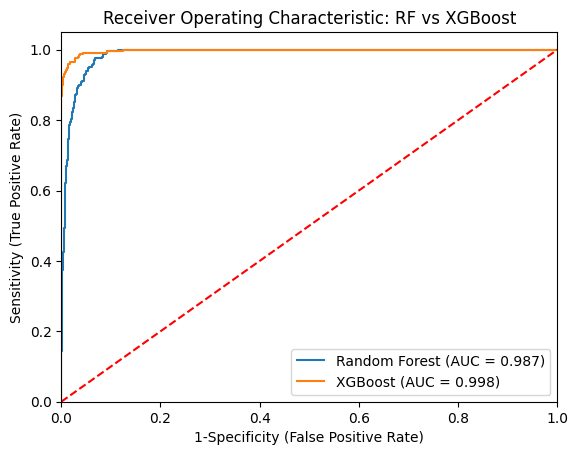

In [74]:
#ROC Curve comparison: Random Forest vs XGBoost
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_proba)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_proba)

plt.plot(rf_fpr, rf_tpr, label='Random Forest (AUC = %0.3f)' % rf_auc)
plt.plot(xgb_fpr, xgb_tpr, label='XGBoost (AUC = %0.3f)' % xgb_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1-Specificity (False Positive Rate)')
plt.ylabel('Sensitivity (True Positive Rate)')
plt.title('Receiver Operating Characteristic: RF vs XGBoost')
plt.legend(loc="lower right")
plt.savefig("auc.png")
plt.show()


In [75]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# ---------------------------------------------------
# Models to compare
# ---------------------------------------------------

models_to_compare = {
    "Logistic Regression": models["Logistic Regression"],

    "Decision Tree": models["Decision Tree"],

    "Random Forest": models["Random Forest"],

    "XGBoost": models["XGBoost"],

    "KNN": models["KNeighborsClassifier"],

    "Tuned KNN": knn_model,

    "Tuned Random Forest": rf_model,

    "Tuned XGBoost": xgb_model
}


# ---------------------------------------------------
# Fit models and calculate metrics
# ---------------------------------------------------

results = []

for name, model in models_to_compare.items():
    # Predictions
    y_pred = model.predict(x_test)
    y_proba = model.predict_proba(x_test)[:, 1]

    # Store results
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "AUC-PR": average_precision_score(y_test, y_proba)
    })


# ---------------------------------------------------
# Create comparison table
# ---------------------------------------------------

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="AUC-PR",
    ascending=False
).reset_index(drop=True)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,AUC-PR
0,Tuned XGBoost,0.989000,0.973684,0.891566,0.930818,0.997626,0.981977
1,Logistic Regression,0.985667,0.896154,0.935743,0.915521,0.997396,0.980711
2,XGBoost,0.990000,0.974026,0.903614,0.937500,0.997074,0.980496
3,Random Forest,0.961333,0.800905,0.710843,0.753191,0.987006,0.871310
4,Tuned Random Forest,0.965000,0.779070,0.807229,0.792899,0.986969,0.861759
5,Decision Tree,0.962333,0.748175,0.823293,0.783939,0.899106,0.630634
6,Tuned KNN,0.735333,0.236715,0.983936,0.381620,0.950236,0.598470
7,KNN,0.817000,0.298928,0.895582,0.448241,0.914767,0.428158
